# Hyperparameter Tuning

### 1. Import required libraries and Load the Reduced Dataset

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease_reduced_dataset.csv to heart_disease_reduced_dataset.csv


In [ ]:
df = pd.read_csv('heart_disease_reduced_dataset.csv')

In [ ]:
df.head()

,PC13,PC5,PC9,PC2,PC12,PC11,PC15,PC1,HeartDisease
0,0.174570,2.767598,-0.012057,2.262340,0.723671,0.567220,0.386863,0.684512,0
1,-0.340249,0.017665,-0.204954,1.260364,0.444649,-0.771801,-0.856000,3.570333,2
2,-0.313430,-0.740147,-1.090397,-0.713093,-0.406428,0.148344,-0.251198,3.402447,1
3,1.884434,0.317091,-0.740746,0.220787,0.964626,0.203725,-0.828009,-1.651317,0
4,0.631125,1.199871,0.087860,-0.457629,-1.421694,0.696152,0.302566,-2.501824,0


### 2. Split features and target

In [ ]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

### 3. Random Forest Hyperparameter Tuning (GridSearchCV)

In [ ]:
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, y_train)

y_pred_baseline = rf_baseline.predict(X_test)

print("Baseline Random Forest Accuracy:", accuracy_score(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline))

Baseline Random Forest Accuracy: 0.9085365853658537
              precision    recall  f1-score   support

           0       0.87      0.82      0.84        33
           1       0.89      0.78      0.83        32
           2       0.94      0.97      0.96        33
           3       0.89      0.97      0.93        33
           4       0.94      1.00      0.97        33

    accuracy                           0.91       164
   macro avg       0.91      0.91      0.91       164
weighted avg       0.91      0.91      0.91       164



In [ ]:
rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9085365853658537


In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.89      0.75      0.81        32
           2       0.97      0.97      0.97        33
           3       0.84      0.97      0.90        33
           4       0.92      1.00      0.96        33

    accuracy                           0.91       164
   macro avg       0.91      0.91      0.91       164
weighted avg       0.91      0.91      0.91       164



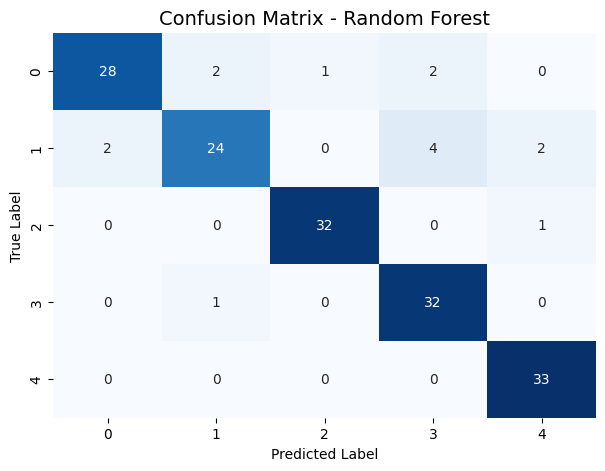

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=rf_best.classes_, yticklabels=rf_best.classes_)

plt.title("Confusion Matrix - Random Forest", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

* Comparison: Baseline vs Tuned Random Forest

Baseline Random Forest Accuracy: 0.9085
Tuned Random Forest Accuracy: 0.9085

=== Baseline Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.82      0.84        33
           1       0.89      0.78      0.83        32
           2       0.94      0.97      0.96        33
           3       0.89      0.97      0.93        33
           4       0.94      1.00      0.97        33

    accuracy                           0.91       164
   macro avg       0.91      0.91      0.91       164
weighted avg       0.91      0.91      0.91       164

=== Tuned Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.89      0.75      0.81        32
           2       0.97      0.97      0.97        33
           3       0.84      0.97      0.90        33
           4       0.92      1.00      0.96        33

    

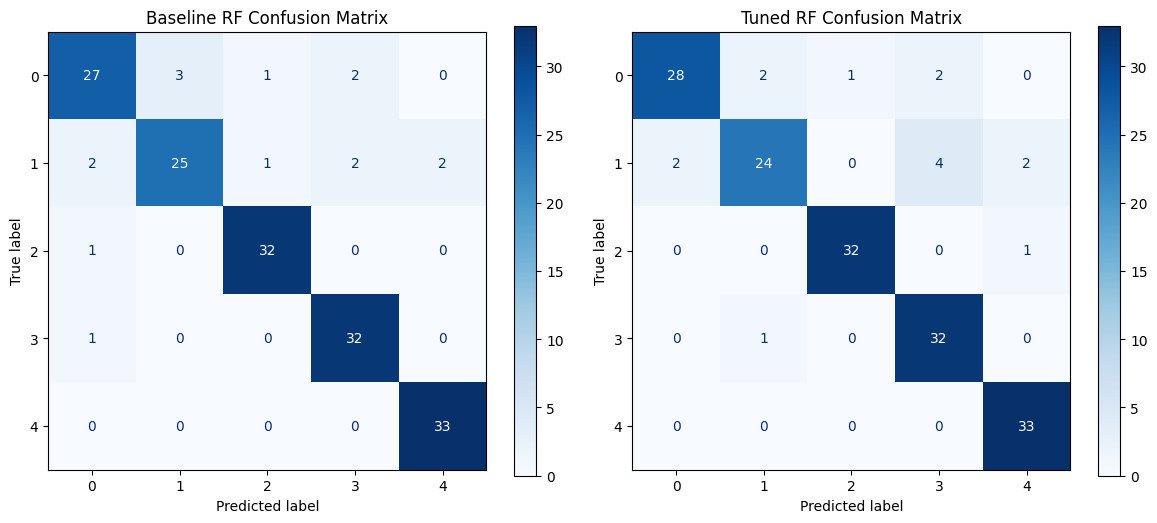

In [ ]:
baseline_acc = accuracy_score(y_test, y_pred_baseline)
tuned_acc = accuracy_score(y_test, y_pred_rf)

print(f"Baseline Random Forest Accuracy: {baseline_acc:.4f}")
print(f"Tuned Random Forest Accuracy: {tuned_acc:.4f}\n")


print("=== Baseline Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_baseline))

print("=== Tuned Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf))


cm_baseline = confusion_matrix(y_test, y_pred_baseline)
cm_tuned = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=np.unique(y))
disp1.plot(ax=axes[0], cmap=plt.cm.Blues, values_format='d')
axes[0].set_title("Baseline RF Confusion Matrix")

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=np.unique(y))
disp2.plot(ax=axes[1], cmap=plt.cm.Blues, values_format='d')
axes[1].set_title("Tuned RF Confusion Matrix")

plt.tight_layout()
plt.show()


# Model Export & Deployment

In [ ]:
joblib.dump(rf_best, 'best_heart_disease_model.pkl')
print("✅ Model saved as 'best_heart_disease_model.pkl'")

✅ Model saved as 'best_heart_disease_model.pkl'


In [ ]:
from google.colab import files

files.download('best_heart_disease_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Recreate the scaler and PCA from Cleaned Dataset to use it on the Streamlit APP